In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

In [22]:
# Carregar base final de modelagem
df = pd.read_csv("../data/refined/dados_modelo.csv")

print("Shape:", df.shape)
df.head()
df["ANO"].value_counts().sort_index()
df["POSSUI_DEFASAGEM"].value_counts(normalize=True)

Shape: (2865, 18)


POSSUI_DEFASAGEM
1    0.588831
0    0.411169
Name: proportion, dtype: float64

In [23]:
#separação de X e Y
X = df.drop(columns=["POSSUI_DEFASAGEM", "ANO", "IAN"], errors="ignore")
y = df["POSSUI_DEFASAGEM"]

X.shape, y.shape

((2865, 15), (2865,))

In [24]:
X

,FASE,IDADE,GENERO,ANO_INGRESSO,INSTITUICAO_ENSINO,IAA,IEG,IPS,IDA,IND_PV,IPP,NOTA_MATEM,NOTA_PORT,INDE_ATUAL,IPP_IMPUTADO
0,7,19.0,1,2016,1.0,8.300,4.100000,5.6000,4.000000,7.278,7.5,2.70,3.5,5.783000,1
1,7,17.0,1,2017,2.0,8.800,5.200000,6.3000,6.800000,6.778,7.5,6.30,4.5,7.055000,1
2,7,17.0,1,2016,2.0,0.000,7.900000,5.6000,5.600000,7.556,7.5,5.80,4.0,6.591000,1
3,7,17.0,0,2017,2.0,8.800,4.500000,5.6000,5.000000,5.278,7.5,2.80,3.5,5.951000,1
4,7,17.0,1,2016,2.0,7.900,8.600000,5.6000,5.200000,7.389,7.5,7.00,2.9,7.427000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2860,7,15.0,0,2022,3.0,8.751,9.737667,6.2600,6.166667,7.500,7.5,6.00,6.5,7.931967,0
2861,7,18.0,0,2021,4.0,6.667,9.704333,6.5700,5.483333,7.500,7.5,6.35,6.3,7.611233,0
2862,7,15.0,0,2021,3.0,10.002,9.920000,6.8850,2.633333,7.500,7.5,0.00,0.0,7.449367,0
2863,7,16.0,0,2021,4.0,8.334,9.246000,6.5725,8.266667,7.500,7.5,8.20,7.8,8.243183,0


In [25]:
features = X.columns.tolist()
print("Features usadas no modelo:")
features

Features usadas no modelo:


['FASE',
 'IDADE',
 'GENERO',
 'ANO_INGRESSO',
 'INSTITUICAO_ENSINO',
 'IAA',
 'IEG',
 'IPS',
 'IDA',
 'IND_PV',
 'IPP',
 'NOTA_MATEM',
 'NOTA_PORT',
 'INDE_ATUAL',
 'IPP_IMPUTADO']

In [26]:
# Treino: anos 2022 e 2023
train_mask = df["ANO"].isin([2022, 2023])
test_mask  = df["ANO"] == 2024

X_train = X[train_mask]
y_train = y[train_mask]

X_test = X[test_mask]
y_test = y[test_mask]

X_train.shape, X_test.shape
y_train.value_counts(normalize=True), y_test.value_counts(normalize=True)

(POSSUI_DEFASAGEM
 1    0.636665
 0    0.363335
 Name: proportion, dtype: float64,
 POSSUI_DEFASAGEM
 1    0.506641
 0    0.493359
 Name: proportion, dtype: float64)

In [27]:
log_clf = LogisticRegression(max_iter=1000, n_jobs=-1)

log_clf.fit(X_train, y_train)

y_pred_log = log_clf.predict(X_test)
y_proba_log = log_clf.predict_proba(X_test)[:, 1]

print("=== Regressão Logística ===")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_log))

print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred_log))

c:\Users\Joyce\Python\mlet_5_tech_challenge\env\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


=== Regressão Logística ===
              precision    recall  f1-score   support

           0       0.98      0.95      0.96       520
           1       0.95      0.98      0.96       534

    accuracy                           0.96      1054
   macro avg       0.96      0.96      0.96      1054
weighted avg       0.96      0.96      0.96      1054

ROC-AUC: 0.995829732065687
Matriz de confusão:
[[492  28]
 [ 12 522]]


c:\Users\Joyce\Python\mlet_5_tech_challenge\env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


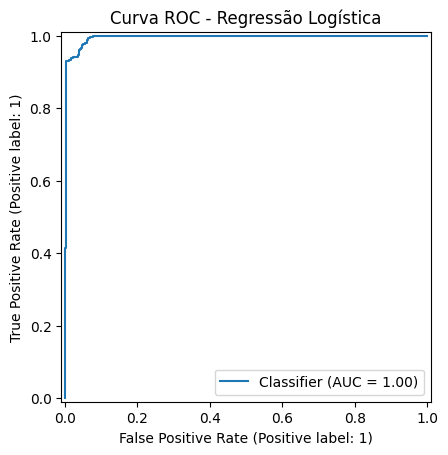

In [28]:
RocCurveDisplay.from_predictions(y_test, y_proba_log)
plt.title("Curva ROC - Regressão Logística")
plt.show()

In [29]:
X.columns

Index(['FASE', 'IDADE', 'GENERO', 'ANO_INGRESSO', 'INSTITUICAO_ENSINO', 'IAA',
       'IEG', 'IPS', 'IDA', 'IND_PV', 'IPP', 'NOTA_MATEM', 'NOTA_PORT',
       'INDE_ATUAL', 'IPP_IMPUTADO'],
      dtype='str')

In [30]:
df.corr(numeric_only=True)["POSSUI_DEFASAGEM"].sort_values(ascending=False)

POSSUI_DEFASAGEM      1.000000
IPP_IMPUTADO          0.146421
IDADE                 0.137679
IPS                  -0.001738
ANO_INGRESSO         -0.026391
IAA                  -0.032129
GENERO               -0.060116
NOTA_PORT            -0.075033
IPP                  -0.075973
NOTA_MATEM           -0.087174
IDA                  -0.108940
IEG                  -0.122511
FASE                 -0.126513
IND_PV               -0.140801
ANO                  -0.157832
INSTITUICAO_ENSINO   -0.179164
INDE_ATUAL           -0.392211
IAN                  -0.992401
Name: POSSUI_DEFASAGEM, dtype: float64

In [31]:
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"  # opcional, ajuda se as classes estiverem desbalanceadas
)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))

print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred_rf))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.88      0.72      0.79       520
           1       0.77      0.90      0.83       534

    accuracy                           0.81      1054
   macro avg       0.82      0.81      0.81      1054
weighted avg       0.82      0.81      0.81      1054

ROC-AUC: 0.883567415730337
Matriz de confusão:
[[375 145]
 [ 52 482]]


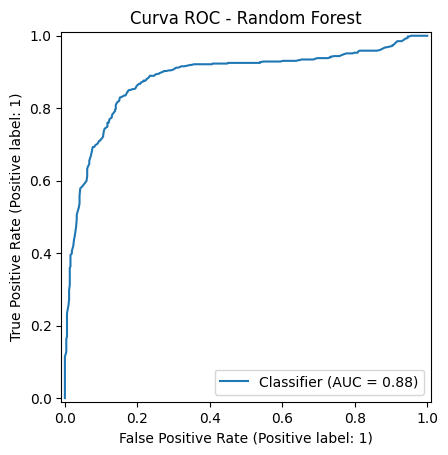

In [33]:
RocCurveDisplay.from_predictions(y_test, y_proba_rf)
plt.title("Curva ROC - Random Forest")
plt.show()

INDE_ATUAL            0.217886
IDADE                 0.176696
IND_PV                0.078220
IDA                   0.071456
FASE                  0.068466
NOTA_MATEM            0.060401
IEG                   0.058852
NOTA_PORT             0.058524
IAA                   0.049658
IPP                   0.045242
IPS                   0.037994
ANO_INGRESSO          0.034897
INSTITUICAO_ENSINO    0.021411
IPP_IMPUTADO          0.010260
GENERO                0.010037
dtype: float64

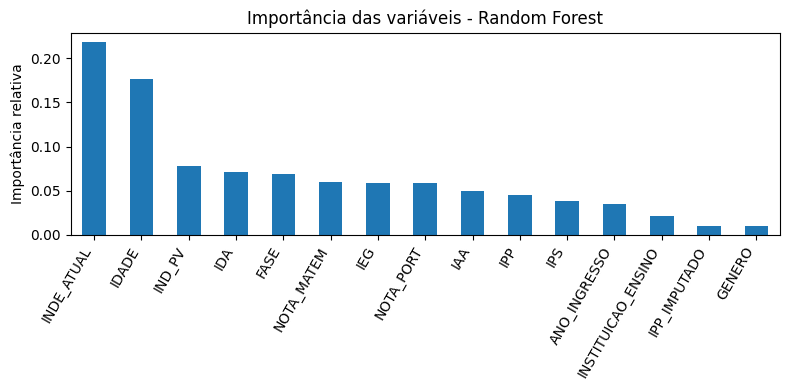

In [34]:
importances = rf_clf.feature_importances_
feat_names = X_train.columns

fi = pd.Series(importances, index=feat_names).sort_values(ascending=False)

display(fi.head(15))

plt.figure(figsize=(8,4))
fi.head(15).plot(kind="bar")
plt.title("Importância das variáveis - Random Forest")
plt.ylabel("Importância relativa")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

In [37]:
df_result = df[test_mask].copy()
df_result["SCORE_RISCO_DEFASAGEM"] = (y_proba_rf * 100).round(2)

df_result[["ANO", "FASE", "INDE_ATUAL", "IPP", "SCORE_RISCO_DEFASAGEM", "POSSUI_DEFASAGEM"]].head()

,ANO,FASE,INDE_ATUAL,IPP,SCORE_RISCO_DEFASAGEM,POSSUI_DEFASAGEM
1811,2024,0,7.611367,5.625,10.67,0
1812,2024,0,8.002867,7.500,10.67,0
1813,2024,0,7.952200,7.500,10.00,0
1814,2024,0,7.156367,6.875,20.33,1
1815,2024,0,5.444200,5.000,80.33,1
